# 🚀 Predict Customer Churn
### *Playground Series S6E3*

---

## 📌 Project Objective
This project aims to predict customer churn using the synthetic dataset from **Playground Series Season 6 Episode 3**. In this notebook, we perform a comprehensive **Exploratory Data Analysis (EDA)** to understand the patterns in customer behavior that lead to churn.

---

## 🗺️ Notebook Structure
1. **Setup & Environment** - Importing libraries and settings.
2. **Data Loading** - Importing train and test datasets.
3. **Dataset Overview** - Checking data types and missing values.
4. **Target Variable Analysis** - Class distribution of Churn.
5. **Numerical Feature Analysis** - Tenure and billing distribution.
6. **Categorical Feature Analysis** - Impact of services and contracts.
7. **Correlation Analysis** - Statistical relationship between features.
8. **Summary & Insights** - Key takeaways for the modeling phase.

---


<a id='setup'></a>
## 1. Setup & Environment

In [2]:
# Core Libraries
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install matplotlib
!pip install seaborn



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Visualization Libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.facecolor'] = '#f8f9fa'

COLORS = ['#7B2CBF', '#C77DFF', '#9D4EDD', '#E0AAFF', '#5A189A']

In [5]:
# Display Settings
pd.set_option('display.max_columns', 50) # display max 50 cols
pd.set_option('display.float_format', '{:.2f}'.format) # show 2 decimals only

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading

In [6]:
TRAIN_PATH = "../Dataset/train.csv"
TEST_PATH  = "../Dataset/test.csv"

In [7]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (594194, 21)
Test shape : (254655, 20)


## 3. Dataset Overview

In [8]:
train.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [9]:
# Check column names and data types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [10]:
# statistical summary of numerical columns
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.00,594194.00,594194.00,594194.00,594194.00
mean,297096.50,0.11,36.58,65.87,2494.38
std,171529.18,0.32,25.06,31.07,2353.92
min,0.00,0.00,1.00,18.25,18.80
25%,148548.25,0.00,12.00,29.90,639.65
50%,297096.50,0.00,35.00,74.10,1433.65
75%,445644.75,0.00,62.00,90.80,4263.80
max,594193.00,1.00,72.00,118.75,8684.80


In [11]:
train.isnull().any()

id                  False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

### 📝 Observations from Dataset Overview

After exploring the dataset structure and statistics, we can summarize the following points:

1.  **Large Dataset:** The training set contains **594,194 records**, providing a rich amount of data for model training.
2.  **Clean Data:** There are **no missing values** across any of the features or the target variable.
3.  **Feature Types:** 
    *   **Numerical:** 3 continuous features (`tenure`, `MonthlyCharges`, `TotalCharges`).
    *   **Categorical:** 16 categorical features (mostly services and account settings).
    *   **Inconsistency:** `SeniorCitizen` is represented as an integer (0, 1), while other binary features are strings (Yes, No).
4.  **Value Ranges:** 
    *   `tenure`: Ranges from 1 to 72 months (median 35).
    *   `MonthlyCharges`: Varies between \$18.25 and \$118.75.


## 4. Target Variable Analysis

In this section, we analyze the distribution of our target variable `Churn` to understand the balance between the two classes (Yes/No).

In [12]:
# Calculate counts and percentages
churn_counts = train['Churn'].value_counts()
churn_pct = train['Churn'].value_counts(normalize=True) * 100

print(f"Churn Counts:\n{churn_counts}")
print(f"\nChurn Percentage:\n{churn_pct.map('{:.2f}%'.format)}")


Churn Counts:
Churn
No     460377
Yes    133817
Name: count, dtype: int64

Churn Percentage:
Churn
No     77.48%
Yes    22.52%
Name: proportion, dtype: object


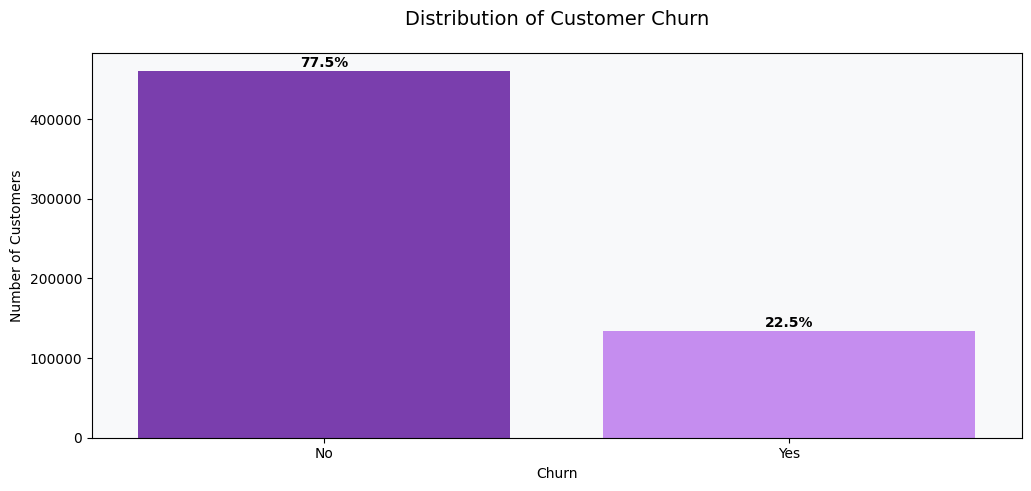

In [13]:
# Visualization
ax = sns.countplot(x='Churn', data=train, palette=COLORS)

# Adding percentages on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 5000,
            f'{height/len(train)*100:.1f}%',
            ha="center", fontweight='bold')

plt.title('Distribution of Customer Churn', fontsize=14, pad=20)
plt.ylabel('Number of Customers')
plt.show()

### 📝 Observations from Target Analysis
*   The target variable `Churn` is **imbalanced**.
*   **77.48%** of customers stayed (No), while **22.52%** churned (Yes).
*   **Decision:** Since the classes are imbalanced, Accuracy might be a misleading metric. We must focus on **ROC-AUC** or **F1-Score** to evaluate our model effectively.


## 5. Numerical Feature Analysis

In this section, we explore the continuous variables: `tenure`, `MonthlyCharges`, and `TotalCharges`. We want to see how their values are distributed and how they relate to the likelihood of churning.


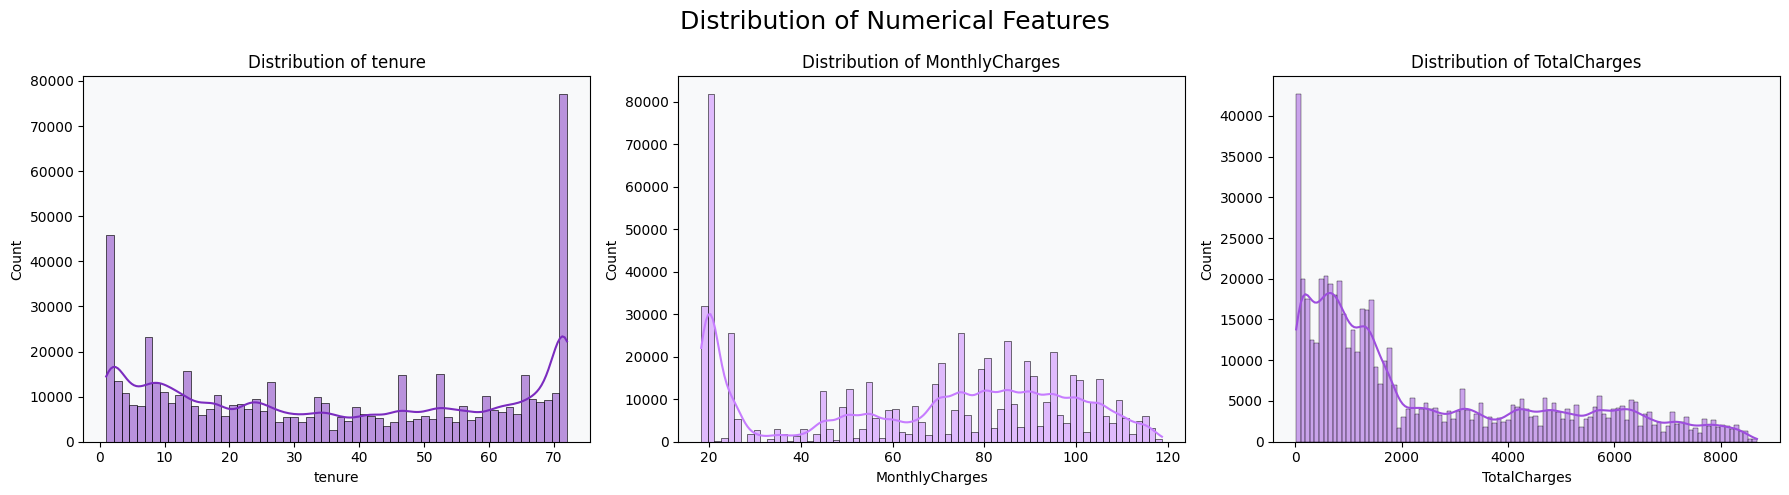

In [14]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Numerical Features', fontsize=18)

for i, col in enumerate(num_features):
    sns.histplot(train[col], kde=True, ax=axes[i], color=COLORS[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


###  5.1 Univariate Analysis: Feature Distributions
Based on the histograms and Kernel Density Estimate (KDE) plots, we observe the following:

*   **Tenure Bimodality:** The `tenure` distribution shows a clear bimodal pattern with peaks at the very beginning (0-5 months) and at the maximum limit (72 months). This indicates the presence of two distinct customer segments: high-risk new joiners and highly loyal long-term veterans.
*   **Monthly Charges Segmentation:** There is a major peak at approximately **$20**, representing budget-conscious users on basic plans. A second, broader cluster appears between **$70 and $110**, indicating customers on high-speed internet or premium service bundles.
*   **Total Charges Skewness:** The distribution is heavily right-skewed. Most customers have lower cumulative spending, while a long tail represents the small percentage of long-term premium subscribers who contribute the most to revenue.


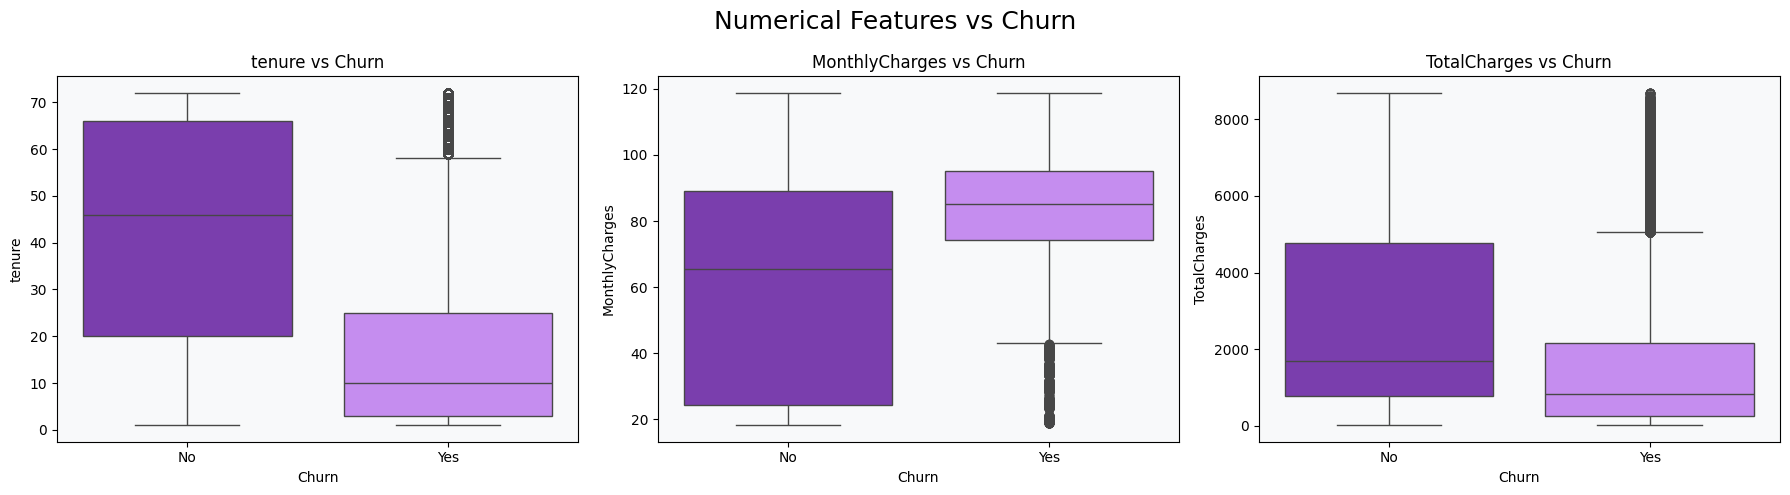

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Numerical Features vs Churn', fontsize=18)

for i, col in enumerate(num_features):
    sns.boxplot(x='Churn', y=col, data=train, ax=axes[i], palette=COLORS)
    axes[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()


###  5.2 Bivariate Analysis: Numerical Features vs Churn
The box plots show clear differences in behavior between customers who stay and those who churn:

*   **Tenure Impact:** There is a significant difference in `tenure`. The median tenure for churned customers (Yes) is approximately **10 months**, whereas for non-churned customers (No), it is roughly **45 months**. This confirms that the risk of churning decreases significantly as customers stay longer with the provider.
*   **Pricing Sensitivity:** Customers who churn tend to have higher `MonthlyCharges` (median **~$85**) compared to those who stay (median **~$65**). This suggests that high monthly pricing is a strong indicator or driver of customer churn.
*   **Total Charges Context:** Churned customers have lower `TotalCharges`. Given their higher monthly bills, this further supports the insight that they leave the service early in their lifecycle, before high total costs can accumulate.


###  Overall Recommendations
Based on the numerical analysis, the following strategies are suggested for churn reduction:

1.  **Early-Stage Retention:** Focus on the "First 12 Months." Implement loyalty programs or check-ins during the first year, as this is the highest risk window for churn.
2.  **Premium Plan Evaluation:** Analyze why high-paying customers ($80+ group) are leaving. Is it due to service quality, competing offers, or lack of perceived value for money?
3.  **Targeted Discounts:** Consider offering introductory or retention discounts specifically aimed at new customers on high-monthly-charge plans to help them transition into long-term loyal users.


## 6. Categorical Feature Analysis

In this section, we explore how different categories (like Contract type, Internet Service, and Payment Method) influence customer churn. Understanding these relationships helps identify high-risk segments.

In [16]:
# Automatically identify categorical columns using a loop
categorical_cols = []
for col in train.columns:
    # If the column is text (object) OR has very few unique values (like 0 and 1)
    if train[col].dtype == 'object' and col != 'Churn':
        categorical_cols.append(col)
    elif train[col].nunique() < 5 and col != 'id': 
        # SeniorCitizen fits here as it only has 2 unique values
        categorical_cols.append(col)

print("Identified Categorical Columns:")
print(categorical_cols)

Identified Categorical Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [18]:
# Calculating churn rate per category to find influential features
influential_check = []

for col in categorical_cols:
    # Get the percentage of 'Yes' for each category in a column
    churn_rate = train.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    diff = churn_rate.max() - churn_rate.min()
    influential_check.append((col, diff))

# Sort features based on the difference in churn rates
# Higher difference means the feature has more influence on Churn
influential_check.sort(key=lambda x: x[1], reverse=True)

print("Features ranked by influence (Churn Rate Difference):")
for feature, score in influential_check:
    print(f"{feature:20} : {score:.4f}")

Features ranked by influence (Churn Rate Difference):
Churn                : 1.0000
PaymentMethod        : 0.4197
Contract             : 0.4106
InternetService      : 0.4011
OnlineSecurity       : 0.3918
TechSupport          : 0.3873
OnlineBackup         : 0.3767
DeviceProtection     : 0.3663
SeniorCitizen        : 0.3105
StreamingMovies      : 0.2850
StreamingTV          : 0.2831
PaperlessBilling     : 0.2448
Dependents           : 0.2186
Partner              : 0.1908
MultipleLines        : 0.1089
PhoneService         : 0.0608
gender               : 0.0057


### 📝 Influence Analysis Findings
By calculating the difference in Churn rates across categories, we identified the most influential features. 
- **Top Influencers:** `PaymentMethod`, `Contract`, `InternetService`, `OnlineSecurity`, and `TechSupport`. These show a >35% difference in churn rates between categories.
- **Low Influence:** `gender` and `PhoneService` show very little impact on churn. Gender, in particular, has almost zero influence (0.57% difference).


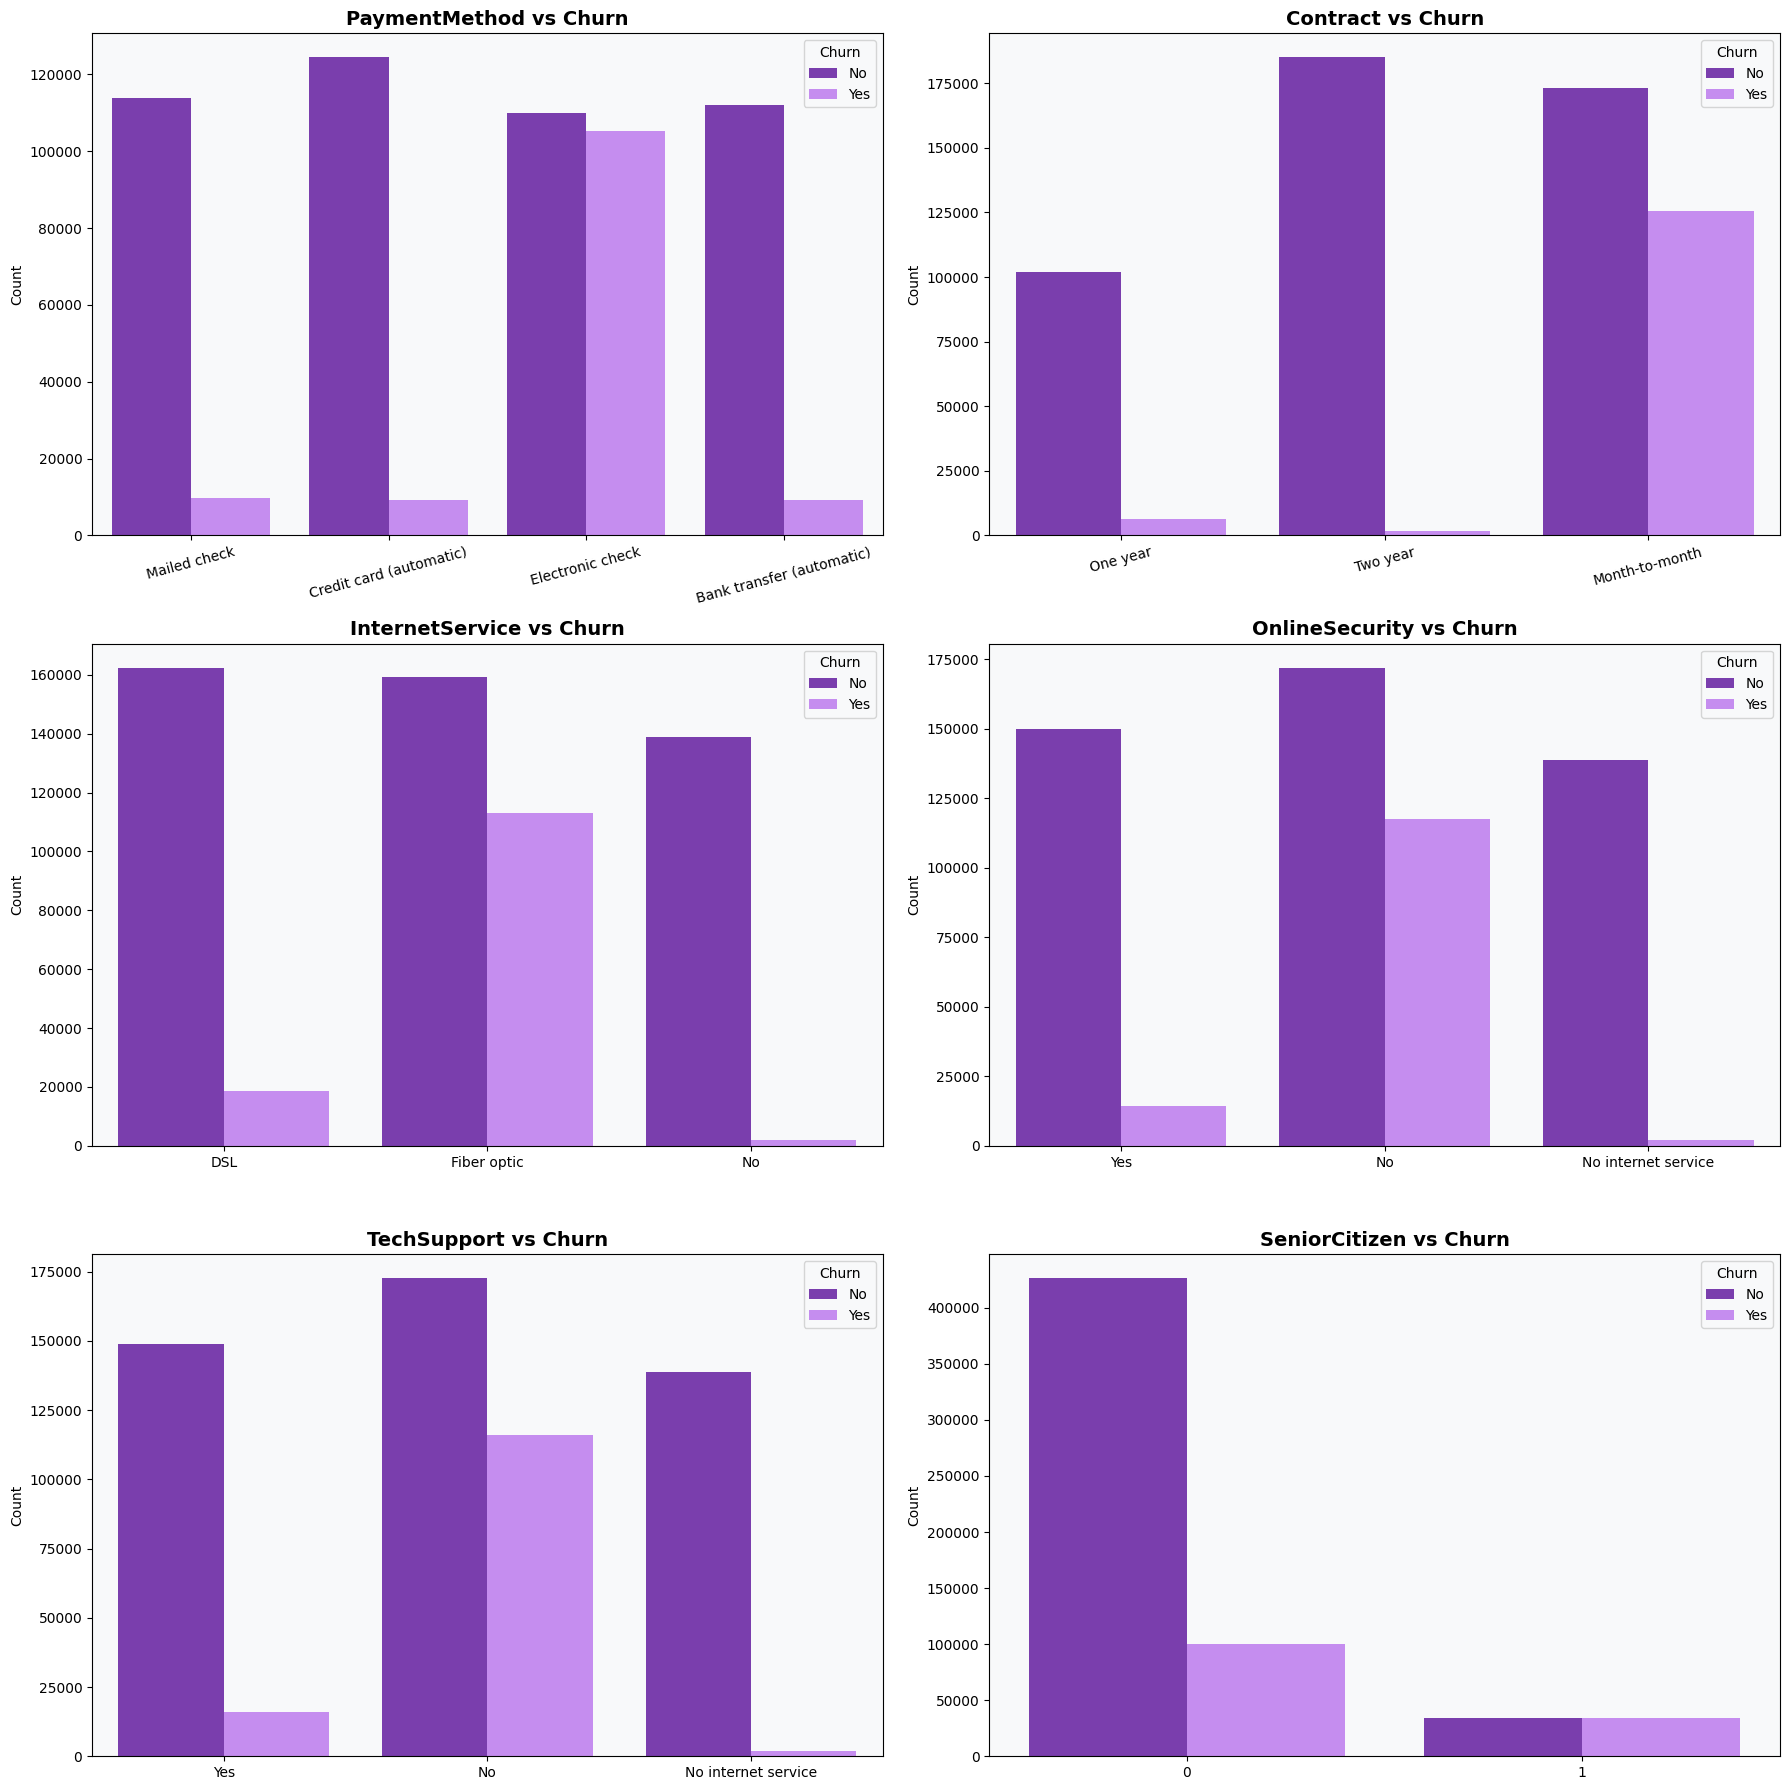

In [20]:
# Select top features based on our influence analysis (excluding Churn and Low score ones)
top_influential_features = ['PaymentMethod', 'Contract', 'InternetService', 
                             'OnlineSecurity', 'TechSupport', 'SeniorCitizen']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(top_influential_features):
    # Create the countplot
    sns.countplot(x=col, hue='Churn', data=train, ax=axes[i], palette=COLORS)
    
    axes[i].set_title(f'{col} vs Churn', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Churn', loc='upper right')
    
    # Cleaning up labels for better visibility
    if col in ['PaymentMethod', 'Contract']:
        axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 📝 Detailed Observations from Categorical Analysis

*   **Payment Method:** Customers using **Electronic check** have a significantly higher churn rate compared to other payment methods. It is nearly 50/50 for stay vs churn in this category. Automated payments (Credit card, Bank transfer) show the highest loyalty.
*   **Contract Type:** The **Month-to-month** contract is the strongest indicator of churn. Thousands of customers leave under this plan, whereas customers on **One year** or **Two year** contracts almost never churn.
*   **Internet Service:** People with **Fiber optic** internet are churning much more than those on **DSL**. This might indicate issues with the price or reliability of the fiber-optic service.
*   **Online Security & TechSupport:** Customers who **do not have** Online Security or Tech Support are far more likely to leave. Providing these services seems to act as a strong retention tool.
*   **Senior Citizen:** While they make up a smaller portion of the dataset, **Senior Citizens (1)** have a much higher churn ratio compared to younger customers.


## 7. Correlation Analysis

To prepare for modeling, we need to understand the relationship between different numerical features and our target variable. We will convert our categorical target `Churn` into a numerical format (0 and 1) to calculate its correlation with other variables.


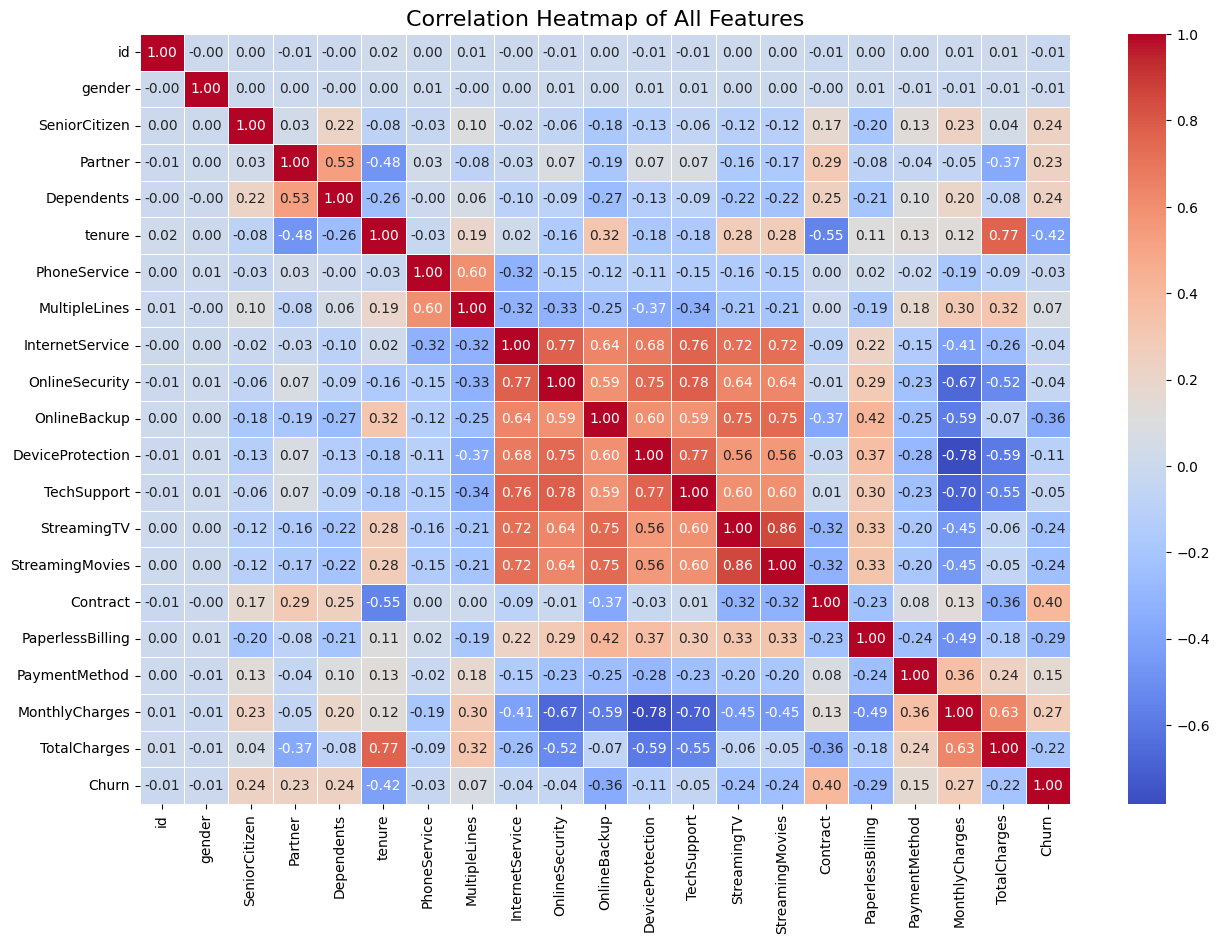

In [21]:
# Temporary dataframe for correlation heatmap
corr_df = train.copy()

# Converting target and categorical binary features to numeric
corr_df['Churn'] = corr_df['Churn'].map({'Yes': 1, 'No': 0})
corr_df['gender'] = corr_df['gender'].map({'Male': 1, 'Female': 0})
# For other categorical columns, we use simple label encoding for correlation check
for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = pd.factorize(corr_df[col])[0]

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Visualization
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.show()


### 📝 Key Insights from Correlation Analysis

*   **Strongest Churn Indicators:** `tenure` (-0.42), `Contract` (0.40), and `MonthlyCharges` (0.27) have the highest correlation with our target variable. This reinforces our earlier visual findings.
*   **High Multicollinearity:** A very strong positive correlation (0.77) exists between `tenure` and `TotalCharges`. This is expected, as long-term customers naturally accumulate higher total costs.
*   **Service Overlap:** There is a significant correlation between high monthly charges and services like `StreamingTV` (0.45) and `InternetService` (0.22 depending on plan), suggesting premium plan users are our high-value but high-risk segment.
*   **Irrelevant Features:** `id` and `gender` show near-zero correlation with churn, suggesting these might not be useful features for our machine learning model.


## 8. Summary & Insights

In this EDA, we have explored nearly 600,000 records to understand what drives customer churn. These insights will now guide our feature engineering and modeling strategies.


In [22]:
# Check for duplicate rows in the training data
duplicates = train.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

if duplicates > 0:
    print("Action needed: Remove duplicates.")
else:
    print("Action: No action needed. Dataset is clean.")


Number of duplicate rows found: 0
Action: No action needed. Dataset is clean.


### 📝 Final EDA Conclusion: What Drives Customer Churn?

After a thorough investigation of the dataset, we have identified the "Profile of a High-Risk Customer":

1.  **Contractual Status:** Customers on **Month-to-month contracts** are the most vulnerable segment.
2.  **Service Period:** Most churn happens within the **first 12 months** of the service.
3.  **Pricing Impact:** High-paying customers (specifically those with **Monthly Charges > $85**) are more likely to leave the company.
4.  **Service Types:** **Fiber-optic** users show higher churn rates than DSL users, possibly indicating service quality or price dissatisfaction.
5.  **Retention Shields:** Having **Online Security** and **Tech Support** services drastically reduces the likelihood of a customer leaving.
6.  **Redundant Data:** Demographic features like **Gender** and **Partner status** play a minimal role in predicting churn compared to financial and service-related features.

---
### 🚀 Next Steps for Modeling:
*   **Feature Engineering:** Remove irrelevant columns like `id` and possibly `gender`.
*   **Handle Imbalance:** Use stratified sampling or specific evaluation metrics (ROC-AUC) to address the 77/23 class imbalance.
*   **Encoding:** Convert categorical text features into numerical format using **One-Hot Encoding** or **Label Encoding**.
*   **Model Selection:** Based on the non-linear relationships observed, Gradient Boosting models like **XGBoost, LightGBM, or CatBoost** are likely to perform best on this tabular data.
